<a href="https://colab.research.google.com/github/J4SIB/ai-course-gp/blob/main/Start_sieci_konwolucyjne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np


(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [25]:
import tensorflow as tf
print("Czy GPU jest dostępne:", tf.config.list_physical_devices('GPU'))

Czy GPU jest dostępne: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [26]:
images_to_check = x_test[:10]
labels_to_check = y_test[:10]

x_test = x_test[10:]
y_test = y_test[10:]



In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import time

start = time.time()

model = Sequential([
    #1. warstwa konwolucyjna
    Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu', padding = "same", input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.30), #25

    #2. warstwa konwolucyjna
    Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu', padding = "same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.30),

    #3. warstwa konwolucyjna
    Conv2D(filters = 128, kernel_size = (3,3), activation = 'relu', padding = "same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.30),

    Flatten(),
    Dense(128, activation = "relu"),
    BatchNormalization(),
    Dropout(0.50), #40

    Dense(10, activation = "softmax"),
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])


history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_test, y_test))


loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Strata: {loss:.4f}, Dokładność: {accuracy:.4f}")

end = time.time()

print(f"czas wykonania: {end - start:.2f} sekund")

#przed - 99.31%
#po(3 warstwa konw (filters128), dropout 25-30 i 40-50) - 99,44%

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8386 - loss: 0.5220 - val_accuracy: 0.9887 - val_loss: 0.0356
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9702 - loss: 0.0964 - val_accuracy: 0.9907 - val_loss: 0.0302
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9768 - loss: 0.0732 - val_accuracy: 0.9907 - val_loss: 0.0265
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9812 - loss: 0.0613 - val_accuracy: 0.9931 - val_loss: 0.0200
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9835 - loss: 0.0562 - val_accuracy: 0.9905 - val_loss: 0.0300
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9846 - loss: 0.0516 - val_accuracy: 0.9927 - val_loss: 0.0213
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9852 - loss: 0.0471 - val_accuracy: 0.9922 - val_loss: 0.0235
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9879 - loss: 0.0397 

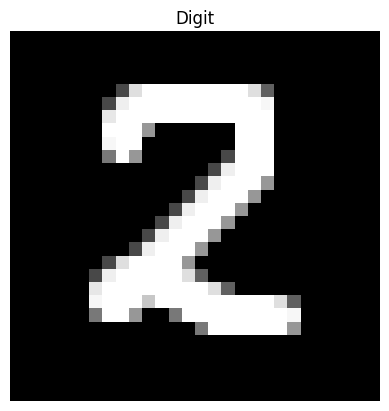

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 2, Prawdopodobieństwo: 1.0000
2. Cyfra: 3, Prawdopodobieństwo: 0.0000
3. Cyfra: 7, Prawdopodobieństwo: 0.0000


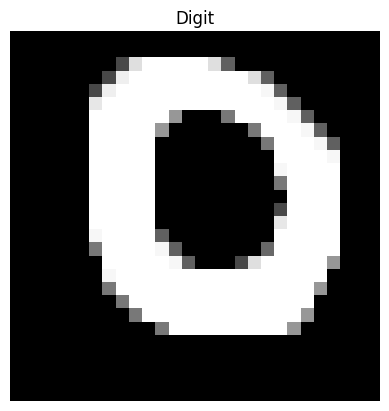

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 0, Prawdopodobieństwo: 0.9998
2. Cyfra: 6, Prawdopodobieństwo: 0.0002
3. Cyfra: 2, Prawdopodobieństwo: 0.0000


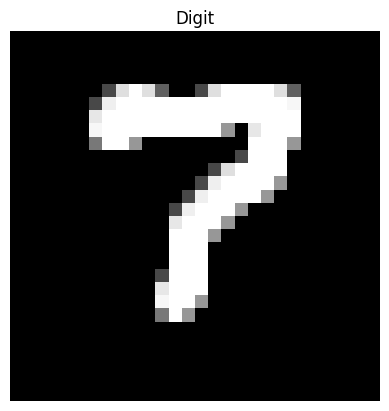

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 3, Prawdopodobieństwo: 0.9392
2. Cyfra: 7, Prawdopodobieństwo: 0.0513
3. Cyfra: 2, Prawdopodobieństwo: 0.0092


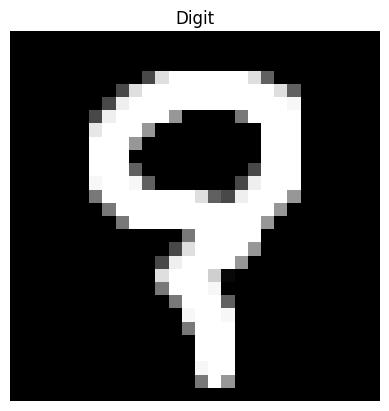

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 8, Prawdopodobieństwo: 0.5450
2. Cyfra: 9, Prawdopodobieństwo: 0.4491
3. Cyfra: 4, Prawdopodobieństwo: 0.0040


In [31]:
from pathlib import Path
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np

for path in Path("images").rglob("*.png"):
  image = Image.open(path).convert('L')
  # zależy od obrazka -> zakomentować dla białej cyfry na czarnym tle
  image = ImageOps.invert(image)

  image = image.resize((28,28))
  image = np.array(image).reshape(1,28,28,1) / 255.0

  plt.imshow(image.reshape(28,28), cmap ="gray")
  plt.title("Digit")
  plt.axis('off')
  plt.show()

  #prediction = model.predict(image)[0]
  #predicted_digit = np.argmax(prediction)

  #print(f"Rozpoznana cyfra : {predicted_digit}")

  prediction = model.predict(image)[0]
  top3_indices = np.argsort(prediction)[-3:][::-1]
  top3_probs = prediction[top3_indices]

  print("Top 3 rozpoznane cyfry:")
  for i, (label, prob) in enumerate(zip(top3_indices, top3_probs), 1):
      print(f"{i}. Cyfra: {label}, Prawdopodobieństwo: {prob:.4f}")
